# Chương 3 – CNN
Nguyễn Minh Vinh · B23DCCN934. Code tự triển khai và kết quả thật. Chạy tuần tự từng cell; các cell train sẽ huấn luyện lại. So sánh scratch / Keras / PyTorch cùng cấu trúc, initialization, split và minibatch.

In [1]:
import os,sys,json
from pathlib import Path
os.environ['OPENBLAS_NUM_THREADS']='2'
os.environ['OMP_NUM_THREADS']='2'
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/experiment.py').exists())
sys.path.insert(0,str(ROOT/'src'))
from IPython.display import display,Image,Code


## 1. Scratch: forward, loss, backward và SGD
NumPy không dùng autograd. MLP áp dụng chain rule; CNN tính gradient kernel từ patch và phân phối gradient average pooling; RNN thực hiện BPTT từ bước cuối về đầu. Gradient clipping global norm=1 trước SGD.

In [2]:
"""NumPy forward/backward/SGD. No automatic differentiation in this module."""
import numpy as np

def initialize(kind,shape,outputs,seed=42):
    rng=np.random.default_rng(seed)
    def w(s,scale):return (rng.normal(size=s)*scale).astype(np.float32)
    if kind=='mlp':return {'w':w((shape[0],32),np.sqrt(2/shape[0])),'b':np.zeros(32,np.float32),'v':w((32,outputs),np.sqrt(1/32)),'c':np.zeros(outputs,np.float32)}
    if kind=='cnn':
        height,width,channels=shape;flat=((height-2)//2)*((width-2)//2)*8
        return {'w':w((3,3,channels,8),np.sqrt(2/(9*channels))),'b':np.zeros(8,np.float32),'v':w((flat,outputs),np.sqrt(1/flat)),'c':np.zeros(outputs,np.float32)}
    return {'w':w((shape[-1],16),np.sqrt(1/shape[-1])),'u':w((16,16),.15),'b':np.zeros(16,np.float32),'v':w((16,outputs),.2),'c':np.zeros(outputs,np.float32)}

def patches(x):
    return np.lib.stride_tricks.sliding_window_view(x,(3,3),axis=(1,2)).transpose(0,1,2,4,5,3)

def forward(p,x,kind,cache=False):
    if kind=='mlp':
        z=x@p['w']+p['b'];h=np.maximum(z,0);aux=(x,z,h)
    elif kind=='cnn':
        cols=patches(x);z=np.tensordot(cols,p['w'],axes=([3,4,5],[0,1,2]))+p['b']
        a=np.maximum(z,0);n,hh,ww,ch=a.shape
        h=a.reshape(n,hh//2,2,ww//2,2,ch).mean((2,4)).reshape(n,-1);aux=(cols,z,h)
    else:
        h=np.zeros((len(x),16),dtype=x.dtype);states=[h]
        for t in range(x.shape[1]):
            h=np.tanh(x[:,t]@p['w']+h@p['u']+p['b']);states.append(h)
        aux=(x,states,h)
    y=h@p['v']+p['c']
    return (y,aux) if cache else y

def objective(logits,y,task,weight=None):
    n=len(y)
    if task=='regression':
        delta=logits[:,0]-y
        return float(np.mean(delta**2)),(2*delta/n)[:,None]
    a=logits-logits.max(1,keepdims=True);exp=np.exp(a);prob=exp/exp.sum(1,keepdims=True)
    weights=np.ones(n) if weight is None else weight[y.astype(int)]
    loss=-(weights*(a[np.arange(n),y.astype(int)]-np.log(exp.sum(1)))).mean()
    grad=prob.copy();grad[np.arange(n),y.astype(int)]-=1;grad*=weights[:,None]/n
    return float(loss),grad

def backward(p,aux,dy,kind):
    x,z,h=aux;g={'v':h.T@dy,'c':dy.sum(0)};dh=dy@p['v'].T
    if kind=='mlp':
        dz=dh*(z>0);g.update(w=x.T@dz,b=dz.sum(0))
    elif kind=='cnn':
        n,hh,ww,ch=z.shape
        pooled=dh.reshape(n,hh//2,ww//2,ch)
        dz=np.repeat(np.repeat(pooled,2,axis=1),2,axis=2)/4*(z>0)
        g.update(w=np.tensordot(x,dz,axes=([0,1,2],[0,1,2])),b=dz.sum((0,1,2)))
    else:
        states=z;g.update(w=np.zeros_like(p['w']),u=np.zeros_like(p['u']),b=np.zeros_like(p['b']))
        for t in range(x.shape[1]-1,-1,-1):
            dz=dh*(1-states[t+1]**2)
            g['w']+=x[:,t].T@dz;g['u']+=states[t].T@dz;g['b']+=dz.sum(0)
            dh=dz@p['u'].T
    return g

def step(p,g,lr,clip=1.):
    norm=np.sqrt(sum(np.sum(v.astype(np.float64)**2) for v in g.values()))
    scale=min(1.,clip/(norm+1e-12))
    for k in p:p[k]-=lr*scale*g[k]

def probabilities(z):
    a=np.exp(z-z.max(1,keepdims=True));return a/a.sum(1,keepdims=True)


## 2. Hai framework cùng cấu trúc
PyTorch dùng ParameterDict và phép toán tensor tự động đạo hàm, đặc biệt RNN chỉ có một bias để trùng với scratch và Keras. Keras dùng Dense/Conv2D/SimpleRNN. Head giữ thứ tự flatten NHWC cho cả ba.

In [3]:
"""Matched architectures with one canonical recurrent bias in every implementation."""
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL','2')
os.environ.setdefault('OMP_NUM_THREADS','2')
os.environ.setdefault('OPENBLAS_NUM_THREADS','2')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS','2')
os.environ.setdefault('TF_NUM_INTEROP_THREADS','1')
import torch
from torch import nn
import tensorflow as tf
import numpy as np
torch.set_num_threads(2)

class TorchModel(nn.Module):
    def __init__(self,p,kind):
        super().__init__();self.kind=kind
        self.params=nn.ParameterDict({k:nn.Parameter(torch.tensor(v.copy())) for k,v in p.items()})
    def forward(self,x):
        p=self.params
        if self.kind=='mlp':h=torch.relu(x@p['w']+p['b'])
        elif self.kind=='cnn':
            a=nn.functional.conv2d(x.permute(0,3,1,2),p['w'].permute(3,2,0,1),p['b'])
            h=nn.functional.avg_pool2d(torch.relu(a),2).permute(0,2,3,1).reshape(len(x),-1)
        else:
            h=torch.zeros((len(x),16),dtype=x.dtype,device=x.device)
            for t in range(x.shape[1]):h=torch.tanh(x[:,t]@p['w']+h@p['u']+p['b'])
        return h@p['v']+p['c']

def keras_model(p,kind,shape):
    layers=tf.keras.layers
    inputs=layers.Input(shape=shape)
    if kind=='mlp':h=layers.Dense(32,activation='relu',name='hidden')(inputs)
    elif kind=='cnn':h=layers.Flatten()(layers.AveragePooling2D(2)(layers.Conv2D(8,3,activation='relu',name='hidden')(inputs)))
    else:h=layers.SimpleRNN(16,activation='tanh',name='hidden')(inputs)
    model=tf.keras.Model(inputs,layers.Dense(p['c'].size,name='head')(h))
    model.get_layer('hidden').set_weights([p['w'],p['u'],p['b']] if kind=='rnn' else [p['w'],p['b']])
    model.get_layer('head').set_weights([p['v'],p['c']]);return model

def export(model,framework,kind):
    if framework=='pytorch':return {k:v.detach().numpy().copy() for k,v in model.params.items()}
    values=model.get_layer('hidden').get_weights();p=dict(zip(['w','u','b'] if kind=='rnn' else ['w','b'],values));p['v'],p['c']=model.get_layer('head').get_weights();return p


## 3. Vòng train và metric
Cùng seed42, SGD không momentum, lr0,02 (MLP/RNN) hoặc0,04(CNN), batch128; epoch18 hoặc20. Chọn checkpoint validation loss nhỏ nhất. Chọn implementation bằng validation MacroF1 hoặc RMSE, rồi đọc test. Loss có class weights train, nhưng metric tính trên test tự nhiên.

In [4]:
from pathlib import Path
import json,time,copy,sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,average_precision_score,roc_auc_score,mean_squared_error,mean_absolute_error,r2_score,confusion_matrix
from sklearn.linear_model import LogisticRegression,Ridge
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
FRAMEWORKS=['scratch','keras','pytorch']
def load(key):
    z=np.load(ROOT/'data'/f'{key}.npz');d={k:z[k] for k in z.files};d['meta']=json.loads((ROOT/'results'/key/'summary.json').read_text(encoding='utf-8'));d['out']=ROOT/'results'/key;return d
def restore_target(d,indices,z):
    meta=d['meta'];v=z[:,0]*meta['y_std']+meta['y_mean']
    return d['last_close'][indices]*np.exp(v) if meta['key']=='stock' else np.expm1(v)
def metrics(d,ix,z):
    if d['meta']['task']=='regression':
        y=d['actual_close'][ix] if d['meta']['key']=='stock' else d['raw_y'][ix];p=restore_target(d,ix,z)
        return dict(RMSE=float(np.sqrt(mean_squared_error(y,p))),MAE=float(mean_absolute_error(y,p)),R2=float(r2_score(y,p)))
    y=d['y'][ix];prob=probabilities(z);pred=prob.argmax(1)
    m=dict(Accuracy=float(accuracy_score(y,pred)),MacroF1=float(f1_score(y,pred,average='macro',zero_division=0)))
    if prob.shape[1]==2:m.update(F1=float(f1_score(y,pred,zero_division=0)),Precision=float(precision_score(y,pred,zero_division=0)),Recall=float(recall_score(y,pred,zero_division=0)),AP=float(average_precision_score(y,prob[:,1])),ROC_AUC=float(roc_auc_score(y,prob[:,1])))
    return m
def predict(p,x,kind,batch=256):return np.concatenate([forward(p,x[i:i+batch],kind) for i in range(0,len(x),batch)])
def train(key,framework,seed=42):
    d=load(key);meta=d['meta'];kind=meta['kind'];task=meta['task'];x=d['x'];y=d['y'];tr,va=d['train'],d['val']
    outputs=len(meta['classes']) if task=='classification' else 1;p=initialize(kind,x.shape[1:],outputs,seed)
    epochs=20 if kind=='cnn' else 18;lr=.04 if kind=='cnn' else .02;batch=128
    weight=None
    if task=='classification':
        counts=np.bincount(y[tr].astype(int),minlength=outputs);weight=(len(tr)/(outputs*counts)).astype(np.float32)
    model=None
    if framework=='pytorch':
        model=TorchModel(p,kind);optimizer=torch.optim.SGD(model.parameters(),lr=lr)
        def update(xb,yb):
            optimizer.zero_grad();z=model(torch.tensor(xb))
            loss=((z[:,0]-torch.tensor(yb))**2).mean() if task=='regression' else (torch.nn.functional.cross_entropy(z,torch.tensor(yb,dtype=torch.long),reduction='none')*torch.tensor(weight)[torch.tensor(yb,dtype=torch.long)]).mean()
            loss.backward();torch.nn.utils.clip_grad_norm_(model.parameters(),1.);optimizer.step();return float(loss.detach())
    elif framework=='keras':
        model=keras_model(p,kind,x.shape[1:]);optimizer=tf.keras.optimizers.SGD(learning_rate=lr,global_clipnorm=1.)
        @tf.function(reduce_retracing=True)
        def update(xb,yb):
            with tf.GradientTape() as tape:
                z=model(xb,training=True)
                loss=tf.reduce_mean(tf.square(z[:,0]-yb)) if task=='regression' else tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=tf.cast(yb,tf.int32),logits=z)*tf.gather(weight,tf.cast(yb,tf.int32)))
            optimizer.apply_gradients(zip(tape.gradient(loss,model.trainable_variables),model.trainable_variables));return loss
    else:
        def update(xb,yb):
            z,cache=forward(p,xb,kind,True);loss,dz=objective(z,yb,task,weight);g=backward(p,cache,dz,kind);step(p,g,lr);return loss
    best=np.inf;history=[];start=time.perf_counter()
    for epoch in range(1,epochs+1):
        order=np.random.default_rng(seed+epoch).permutation(tr);total=0
        for i in range(0,len(order),batch):
            ix=order[i:i+batch];total+=float(update(x[ix],y[ix]))*len(ix)
        if model is not None:p=export(model,framework,kind)
        val=objective(predict(p,x[va],kind),y[va],task,weight)[0]
        history.append(dict(epoch=epoch,train_loss=total/len(tr),val_loss=val))
        if val<best:best=val;bestp=copy.deepcopy(p);bestepoch=epoch
        print(key,framework,epoch,round(val,5),flush=True)
    seconds=time.perf_counter()-start;p=bestp;name=f'{framework}_{seed}';out=d['out'];np.savez_compressed(out/f'{name}.npz',**p)
    pd.DataFrame(history).to_csv(out/f'{name}_history.csv',index=False)
    validation=metrics(d,va,predict(p,x[va],kind));test=predict(p,x[d['test']],kind);np.savez_compressed(out/f'{name}_predictions.npz',logits=test,indices=d['test'])
    row=dict(framework=framework,seed=seed,epochs=epochs,best_epoch=bestepoch,lr=lr,batch=batch,parameters=sum(v.size for v in p.values()),seconds=seconds,validation=validation,test=metrics(d,d['test'],test))
    (out/f'{name}.json').write_text(json.dumps(row,indent=2))
    if framework=='pytorch':torch.save(TorchModel(p,kind).state_dict(),out/f'{name}.pth')
    elif framework=='keras':keras_model(p,kind,x.shape[1:]).save(out/f'{name}.keras')
    return row

def summarize(key):
    d=load(key);out=d['out'];meta=d['meta'];rows=[json.loads((out/f'{fw}_42.json').read_text()) for fw in FRAMEWORKS]
    criterion='RMSE' if meta['task']=='regression' else 'MacroF1'
    selected=sorted(rows,key=lambda r:r['validation'][criterion],reverse=meta['task']=='classification')[0]['framework']
    (out/'selection.json').write_text(json.dumps(dict(framework=selected,criterion=criterion,split='validation')))
    table=pd.DataFrame([dict(Framework=r['framework'],**r['test'],Parameters=r['parameters'],TrainSeconds=r['seconds'],BestEpoch=r['best_epoch']) for r in rows]);table.to_csv(out/'comparison.csv',index=False)
    fig,axes=plt.subplots(1,3,figsize=(12,3.2))
    for ax,fw in zip(axes,FRAMEWORKS):
        h=pd.read_csv(out/f'{fw}_42_history.csv');ax.plot(h.epoch,h.train_loss,label='train');ax.plot(h.epoch,h.val_loss,label='val');ax.set_title(fw);ax.legend()
    fig.tight_layout();fig.savefig(out/'learning.png',dpi=150);plt.close(fig)
    te=d['test'];z=np.load(out/f'{selected}_42_predictions.npz')['logits']
    fig,axes=plt.subplots(1,2,figsize=(10,3.5))
    if meta['task']=='classification':
        counts=np.bincount(d['y'].astype(int));axes[0].bar(np.arange(len(counts)),counts);axes[0].set_title('Benchmark label counts')
        cm=confusion_matrix(d['y'][te],z.argmax(1));axes[1].imshow(cm,cmap='Blues');axes[1].set_title(selected+' test confusion')
        for a in range(len(cm)):
            for b in range(len(cm)):axes[1].text(b,a,str(cm[a,b]),ha='center',va='center',fontsize=6)
        baseline_pred=np.full(len(te),np.bincount(d['y'][d['train']].astype(int)).argmax());base=dict(Accuracy=float(accuracy_score(d['y'][te],baseline_pred)),MacroF1=float(f1_score(d['y'][te],baseline_pred,average='macro',zero_division=0)))
        errors=np.flatnonzero(z.argmax(1)!=d['y'][te])[:8];examples=[dict(index=int(te[i]),actual=int(d['y'][te[i]]),prediction=int(z[i].argmax()),score=float(probabilities(z[i:i+1]).max())) for i in errors]
    else:
        actual=d['actual_close'][te] if key=='stock' else d['raw_y'][te];pred=restore_target(d,te,z)
        axes[0].hist(actual,bins=40);axes[0].set_title('Test target distribution')
        axes[1].scatter(actual,pred,s=5,alpha=.4);axes[1].plot([actual.min(),actual.max()],[actual.min(),actual.max()],'k--');axes[1].set(xlabel='Actual',ylabel='Prediction')
        b=d['last_close'][te] if key=='stock' else np.full(len(te),d['raw_y'][d['train']].mean());base=dict(RMSE=float(np.sqrt(mean_squared_error(actual,b))),MAE=float(mean_absolute_error(actual,b)),R2=float(r2_score(actual,b)))
        errors=np.argsort(abs(pred-actual))[-8:][::-1];examples=[dict(index=int(te[i]),actual=float(actual[i]),prediction=float(pred[i]),absolute_error=float(abs(pred[i]-actual[i]))) for i in errors]
    fig.tight_layout();fig.savefig(out/'evaluation.png',dpi=150);plt.close(fig)
    (out/'baseline.json').write_text(json.dumps(base,indent=2));(out/'errors.json').write_text(json.dumps(examples,indent=2))
    # Three observed input/output examples, not predictions invented for the report.
    examples=[]
    for ix in te[:3]:examples.append(dict(index=int(ix),input=np.round(d['x'][ix].reshape(-1)[:8],3).tolist(),target=float(d['raw_y'][ix])))
    (out/'samples.json').write_text(json.dumps(examples,indent=2))
    if meta['kind']=='cnn':
        fig,axes=plt.subplots(2,5,figsize=(10,4))
        for label,ax in enumerate(axes.flat):
            i=te[np.flatnonzero(d['y'][te]==label)[0]];ax.imshow(d['images'][i].squeeze(),cmap='gray' if key=='mnist' else None);ax.set_title(meta['classes'][label],fontsize=8);ax.axis('off')
        fig.tight_layout();fig.savefig(out/'samples.png',dpi=150);plt.close(fig)
    return table


## 4. Dataset mnist
MNIST: 10.000 train, 2.000 validation lấy từ train chính thức, 2.000 test từ test chính thức. Resize 16×16 để scratch CNN train được trên CPU; không dùng pretrained. CNN valid3×3 → ReLU → average pool2 → flatten → logits10.

In [5]:
import subprocess
if not (ROOT/'data/mnist.npz').exists():
    subprocess.run([sys.executable,str(ROOT/'tools/prepare.py'),'mnist'],check=True)
data=load('mnist')
display(pd.Series(data['meta']))
print('Input shape:',data['x'].shape)
display(pd.DataFrame(data['x'][data['train'][:3]].reshape(3,-1)[:,:8]))
print('Nhãn mẫu:',data['raw_y'][data['train'][:3]])

kind                                                       cnn
task                                            classification
classes                         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
raw_rows                                                 70000
mean                                     [0.13107748329639435]
std                                       [0.2632492780685425]
source       https://storage.googleapis.com/tensorflow/tf-k...
protocol     Fixed stratified benchmark subset; MNIST prese...
transform    Resize16 bilinear /255 then train channel mean...
key                                                      mnist
shape                                              [16, 16, 1]
samples                                                  14000
splits             {'train': 10000, 'val': 2000, 'test': 2000}
counts       {'train': [987, 1124, 993, 1022, 974, 904, 986...
dtype: object

Input shape: (14000, 16, 16, 1)


,0,1,2,3,4,5,6,7
0,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922
1,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922
2,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922,-0.497922


Nhãn mẫu: [6 5 8]


### Tiền xử lý cụ thể
Mã chuẩn bị dữ liệu được trình bày dưới đây để đối chiếu fit scope và nguồn. Khi cần tái tạo cache, chạy tools/prepare.py với tên dataset. Chuỗi thời gian có thêm prepare_sequences.py.

In [6]:
display(Code(filename=str(ROOT/'tools/prepare.py'),language='python'))

from pathlib import Path
import json,sys,io,zipfile,hashlib
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,GroupShuffleSplit
ROOT=Path(__file__).resolve().parents[1]
DATA=ROOT/'data'
def save(key,x,y,split,meta,extras=None):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    meta.update(key=key,shape=list(x.shape[1:]),samples=len(y),splits={k:len(v) for k,v in split.items()})
    if meta['task']=='classification':meta['counts']={k:np.bincount(y[v].astype(int),minlength=len(meta['classes'])).tolist() for k,v in split.items()}
    np.savez_compressed(DATA/f'{key}.npz',x=x.astype(np.float32),y=y,**split,**(extras or {}))
    (out/'summary.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,meta['splits'],flush=True)

def split_random(y):
    ix=np.arange(len(y));tr,te=train_test_split(ix,test_size=.2,random_state=42,stratify=y)
    tr,va=train_test_split(tr,test_size=.2,random_state=42,stratify=y[tr]);return dict(train=tr,val=va,test=te)

def tabular(key):
    if key=='diabetes':
        df=pd.read_csv(DATA/'diabetes.csv');raw_count=len(df);df=df.drop_duplicates()
        target=(df.pop('Diabetes_012').to_numpy()>0).astype(np.int64)
        features=list(df);raw=df.to_numpy(np.float32);groups=pd.util.hash_pandas_object(df,index=False).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw,target,groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw[tr],target[tr],groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        # Subset each split by labels after grouping; no identical predictor crosses splits.
        for k,n in [('train',16000),('val',4000),('test',5000)]:
            ix=split[k]
            if len(ix)>n:split[k]=train_test_split(ix,train_size=n,random_state=42,stratify=target[ix])[0]
        chosen=np.concatenate(list(split.values()));mapping={int(v):i for i,v in enumerate(chosen)}
        split={k:np.array([mapping[int(v)] for v in ix]) for k,ix in split.items()};raw=raw[chosen];y=target[chosen]
        meta=dict(kind='mlp',task='classification',classes=['No diabetes','Prediabetes or diabetes'],raw_rows=raw_count,features=features,source='https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset',protocol='Group by identical predictors; bounded stratified subsets within splits',transform='train mean/std')
    else:
        df=pd.read_csv(DATA/'house_prices.csv');raw_count=len(df);df=df.drop_duplicates()
        df=df[(df.Area>0)&(df.Price>0)].copy()
        features=['Area','Frontage','Access Road','Floors','Bedrooms','Bathrooms']
        raw=df[features].to_numpy(np.float32);raw[raw<0]=np.nan
        groups=df.Address.fillna('Unknown').astype(str).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df,groups=groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df.iloc[tr],groups=groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        median=np.nanmedian(raw[split['train']],axis=0);raw=np.where(np.isnan(raw),median,raw);y=df.Price.to_numpy(np.float32)
        meta=dict(kind='mlp',task='regression',raw_rows=raw_count,features=features,median=median.tolist(),source='https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024',protocol='Group split by exact Address, 64/16/20 approximate rows; no location feature',transform='log1p numeric, train mean/std',unit='billion VND')
        raw=np.log1p(raw)
    mean=raw[split['train']].mean(0);std=raw[split['train']].std(0);std[std<1e-6]=1
    meta.update(mean=mean.tolist(),std=std.tolist())
    if key=='housing':
        z=np.log1p(y);ym=z[split['train']].mean();ys=z[split['train']].std();meta.update(y_mean=float(ym),y_std=float(ys));extras={'raw_y':y};y=(z-ym)/ys
    else:extras={'raw_y':y}
    save(key,(raw-mean)/std,y,split,meta,extras)



### Huấn luyện scratch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [7]:
row=train('mnist','scratch')
display(row)

mnist scratch 1 0.60756


mnist scratch 2 0.43206


mnist scratch 3 0.38653


mnist scratch 4 0.36492


mnist scratch 5 0.33347


...

mnist scratch 17 0.22109


mnist scratch 18 0.22166


mnist scratch 19 0.2159


mnist scratch 20 0.20499


{'framework': 'scratch',
 'seed': 42,
 'epochs': 20,
 'best_epoch': 20,
 'lr': 0.04,
 'batch': 128,
 'parameters': 4010,
 'seconds': 9.871573199983686,
 'validation': {'Accuracy': 0.944, 'MacroF1': 0.9435535718427429},
 'test': {'Accuracy': 0.9405, 'MacroF1': 0.9399979606254509}}

### Huấn luyện keras
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [8]:
row=train('mnist','keras')
display(row)

mnist keras 1 0.60756


mnist keras 2 0.43206


mnist keras 3 0.38653


mnist keras 4 0.36492


mnist keras 5 0.33347


...

mnist keras 17 0.22109


mnist keras 18 0.22166


mnist keras 19 0.2159


mnist keras 20 0.20499


{'framework': 'keras',
 'seed': 42,
 'epochs': 20,
 'best_epoch': 20,
 'lr': 0.04,
 'batch': 128,
 'parameters': 4010,
 'seconds': 5.071639299974777,
 'validation': {'Accuracy': 0.944, 'MacroF1': 0.9435535718427429},
 'test': {'Accuracy': 0.9405, 'MacroF1': 0.9399979606254509}}

### Huấn luyện pytorch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [9]:
row=train('mnist','pytorch')
display(row)

mnist pytorch 1 0.60756


mnist pytorch 2 0.43206


mnist pytorch 3 0.38653


mnist pytorch 4 0.36492


mnist pytorch 5 0.33347


...

mnist pytorch 17 0.22109


mnist pytorch 18 0.22166


mnist pytorch 19 0.2159


mnist pytorch 20 0.20499


{'framework': 'pytorch',
 'seed': 42,
 'epochs': 20,
 'best_epoch': 20,
 'lr': 0.04,
 'batch': 128,
 'parameters': 4010,
 'seconds': 5.665784599957988,
 'validation': {'Accuracy': 0.944, 'MacroF1': 0.9435535718427429},
 'test': {'Accuracy': 0.9405, 'MacroF1': 0.9399979606254509}}

### So sánh và phân tích
Đọc số liệu và hình do các lần train vừa tạo. Metric giữa các framework gần nhau là điều có thể xảy ra khi cùng khởi tạo và cùng SGD; không tự suy ra framework nào tốt hơn từ một seed.

,Framework,Accuracy,MacroF1,Parameters,TrainSeconds,BestEpoch
0,scratch,0.9405,0.94,4010,9.87157,20
1,keras,0.9405,0.94,4010,5.07164,20
2,pytorch,0.9405,0.94,4010,5.66578,20


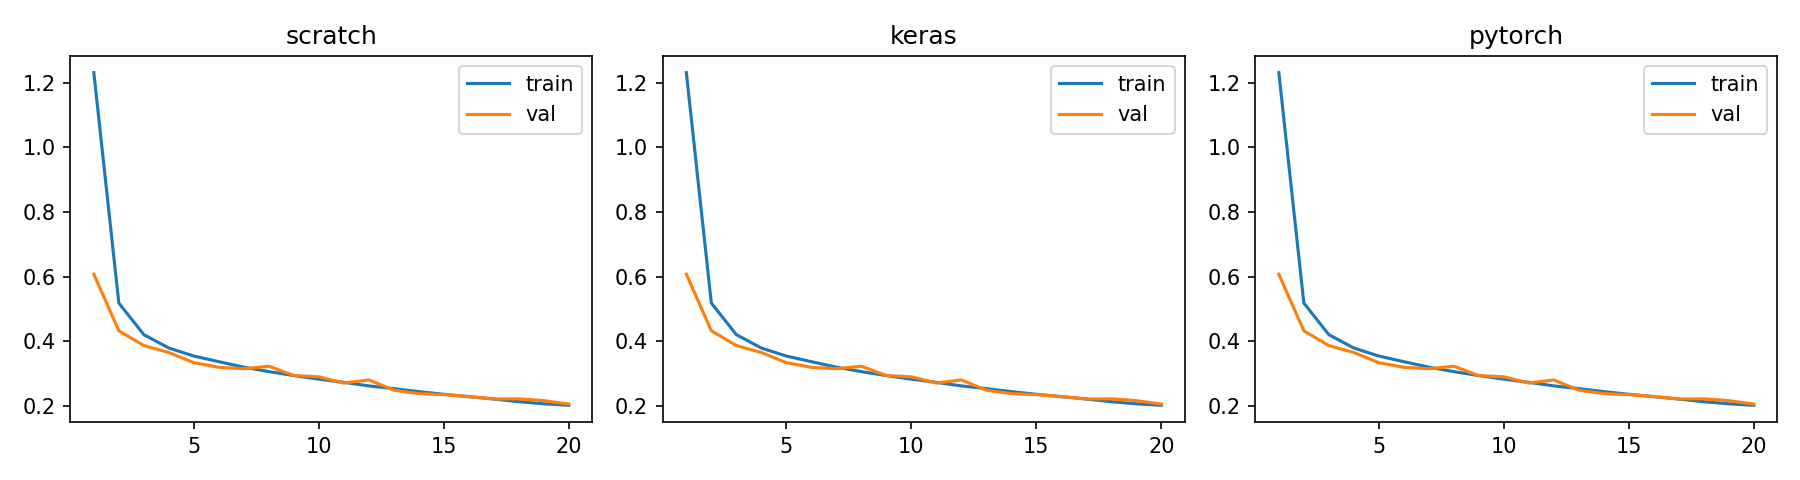

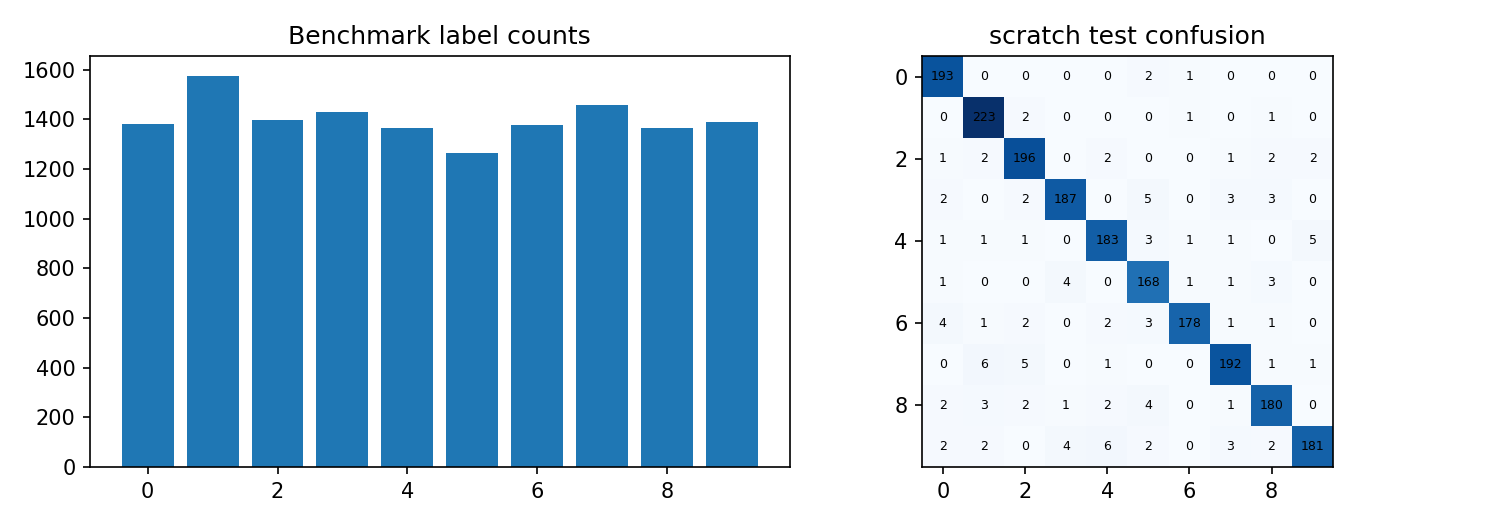

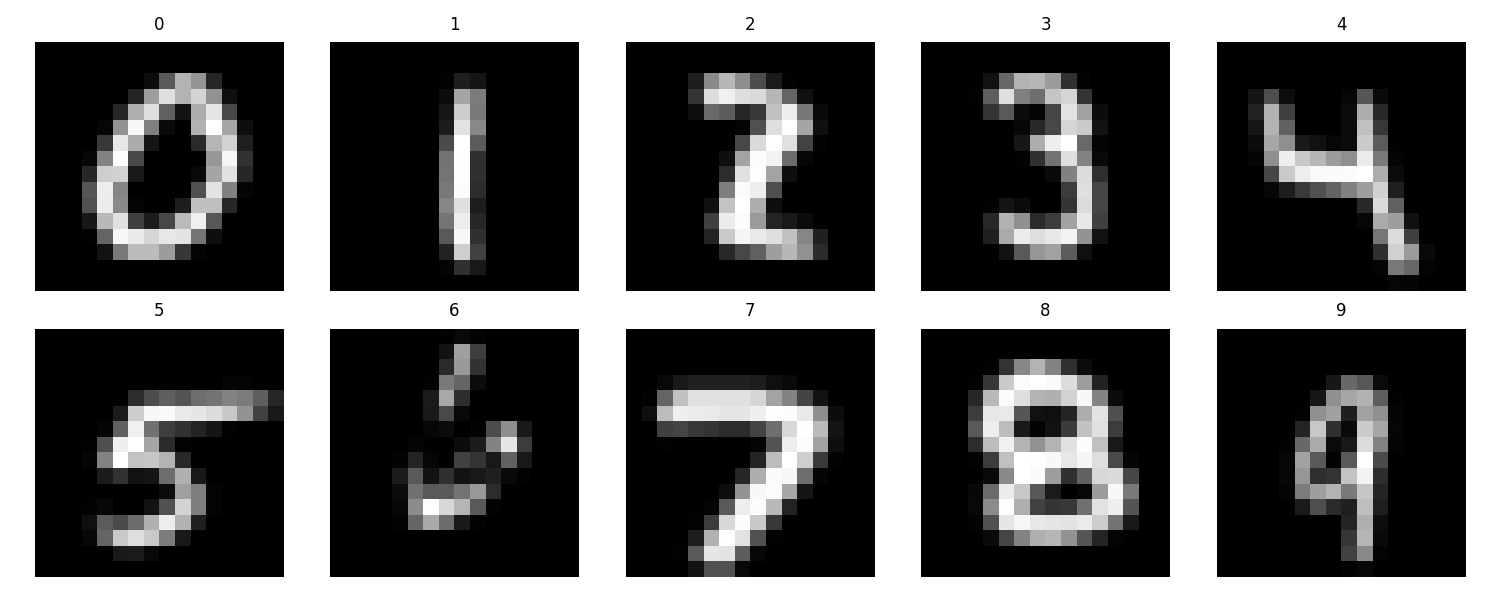

Baseline: {
  "Accuracy": 0.1135,
  "MacroF1": 0.0203861697350696
}
Chọn validation: {"framework": "scratch", "criterion": "MacroF1", "split": "validation"}


,index,actual,prediction,score
0,12150,8,0,0.788319
1,12154,0,5,0.862015
2,12165,9,1,0.472628
3,12170,9,5,0.335892
4,12173,4,9,0.360160
5,12178,3,8,0.862896
6,12183,3,5,0.477757
7,12187,7,8,0.497425


In [10]:
display(summarize('mnist').round(5))
for file in ['learning.png','evaluation.png','samples.png']:
    path=ROOT/'results/mnist'/file
    if path.exists():display(Image(filename=str(path)))
print('Baseline:',(ROOT/'results/mnist/baseline.json').read_text())
print('Chọn validation:',(ROOT/'results/mnist/selection.json').read_text())
display(pd.read_json(ROOT/'results/mnist/errors.json'))

## 4. Dataset eurosat
EuroSAT: nguồn 27.000 ảnh RGB, chọn phân tầng 10.000 ảnh, chia 6.400/1.600/2.000. Resize16, mean/std từng kênh chỉ train. Đây là benchmark nhỏ, không phải kết quả đầy đủ ảnh 64×64. Không spatial split nên chưa khẳng định khái quát sang địa lý mới.

In [11]:
import subprocess
if not (ROOT/'data/eurosat.npz').exists():
    subprocess.run([sys.executable,str(ROOT/'tools/prepare.py'),'eurosat'],check=True)
data=load('eurosat')
display(pd.Series(data['meta']))
print('Input shape:',data['x'].shape)
display(pd.DataFrame(data['x'][data['train'][:3]].reshape(3,-1)[:,:8]))
print('Nhãn mẫu:',data['raw_y'][data['train'][:3]])

kind                                                       cnn
task                                            classification
classes      [AnnualCrop, Forest, HerbaceousVegetation, Hig...
raw_rows                                                 27000
mean         [0.34342673420906067, 0.3801611661911011, 0.40...
std          [0.19104278087615967, 0.12556222081184387, 0.1...
source                      https://zenodo.org/records/7711810
protocol     Fixed stratified benchmark subset; MNIST prese...
transform    Resize16 bilinear /255 then train channel mean...
key                                                    eurosat
shape                                              [16, 16, 3]
samples                                                  10000
splits              {'train': 6400, 'val': 1600, 'test': 2000}
counts       {'train': [711, 711, 711, 593, 593, 474, 593, ...
dtype: object

Input shape: (10000, 16, 16, 3)


,0,1,2,3,4,5,6,7
0,-0.750757,-0.747730,-0.560854,-0.750757,-0.747730,-0.598248,-0.771284,-0.778962
1,-0.052833,-0.091857,-0.747824,-0.175996,-0.123089,-0.785218,-0.442849,-0.341713
2,0.480873,0.657713,1.196664,0.172966,0.220464,0.673148,0.316656,0.345392


Nhãn mẫu: [9 0 7]


### Tiền xử lý cụ thể
Mã chuẩn bị dữ liệu được trình bày dưới đây để đối chiếu fit scope và nguồn. Khi cần tái tạo cache, chạy tools/prepare.py với tên dataset. Chuỗi thời gian có thêm prepare_sequences.py.

In [12]:
display(Code(filename=str(ROOT/'tools/prepare.py'),language='python'))

from pathlib import Path
import json,sys,io,zipfile,hashlib
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,GroupShuffleSplit
ROOT=Path(__file__).resolve().parents[1]
DATA=ROOT/'data'
def save(key,x,y,split,meta,extras=None):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    meta.update(key=key,shape=list(x.shape[1:]),samples=len(y),splits={k:len(v) for k,v in split.items()})
    if meta['task']=='classification':meta['counts']={k:np.bincount(y[v].astype(int),minlength=len(meta['classes'])).tolist() for k,v in split.items()}
    np.savez_compressed(DATA/f'{key}.npz',x=x.astype(np.float32),y=y,**split,**(extras or {}))
    (out/'summary.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,meta['splits'],flush=True)

def split_random(y):
    ix=np.arange(len(y));tr,te=train_test_split(ix,test_size=.2,random_state=42,stratify=y)
    tr,va=train_test_split(tr,test_size=.2,random_state=42,stratify=y[tr]);return dict(train=tr,val=va,test=te)

def tabular(key):
    if key=='diabetes':
        df=pd.read_csv(DATA/'diabetes.csv');raw_count=len(df);df=df.drop_duplicates()
        target=(df.pop('Diabetes_012').to_numpy()>0).astype(np.int64)
        features=list(df);raw=df.to_numpy(np.float32);groups=pd.util.hash_pandas_object(df,index=False).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw,target,groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw[tr],target[tr],groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        # Subset each split by labels after grouping; no identical predictor crosses splits.
        for k,n in [('train',16000),('val',4000),('test',5000)]:
            ix=split[k]
            if len(ix)>n:split[k]=train_test_split(ix,train_size=n,random_state=42,stratify=target[ix])[0]
        chosen=np.concatenate(list(split.values()));mapping={int(v):i for i,v in enumerate(chosen)}
        split={k:np.array([mapping[int(v)] for v in ix]) for k,ix in split.items()};raw=raw[chosen];y=target[chosen]
        meta=dict(kind='mlp',task='classification',classes=['No diabetes','Prediabetes or diabetes'],raw_rows=raw_count,features=features,source='https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset',protocol='Group by identical predictors; bounded stratified subsets within splits',transform='train mean/std')
    else:
        df=pd.read_csv(DATA/'house_prices.csv');raw_count=len(df);df=df.drop_duplicates()
        df=df[(df.Area>0)&(df.Price>0)].copy()
        features=['Area','Frontage','Access Road','Floors','Bedrooms','Bathrooms']
        raw=df[features].to_numpy(np.float32);raw[raw<0]=np.nan
        groups=df.Address.fillna('Unknown').astype(str).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df,groups=groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df.iloc[tr],groups=groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        median=np.nanmedian(raw[split['train']],axis=0);raw=np.where(np.isnan(raw),median,raw);y=df.Price.to_numpy(np.float32)
        meta=dict(kind='mlp',task='regression',raw_rows=raw_count,features=features,median=median.tolist(),source='https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024',protocol='Group split by exact Address, 64/16/20 approximate rows; no location feature',transform='log1p numeric, train mean/std',unit='billion VND')
        raw=np.log1p(raw)
    mean=raw[split['train']].mean(0);std=raw[split['train']].std(0);std[std<1e-6]=1
    meta.update(mean=mean.tolist(),std=std.tolist())
    if key=='housing':
        z=np.log1p(y);ym=z[split['train']].mean();ys=z[split['train']].std();meta.update(y_mean=float(ym),y_std=float(ys));extras={'raw_y':y};y=(z-ym)/ys
    else:extras={'raw_y':y}
    save(key,(raw-mean)/std,y,split,meta,extras)



### Huấn luyện scratch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [13]:
row=train('eurosat','scratch')
display(row)

eurosat scratch 1 1.80195


eurosat scratch 2 1.66492


eurosat scratch 3 1.56918


eurosat scratch 4 1.49439


eurosat scratch 5 1.42654


...

eurosat scratch 17 1.14746


eurosat scratch 18 1.16665


eurosat scratch 19 1.13731


eurosat scratch 20 1.12351


{'framework': 'scratch',
 'seed': 42,
 'epochs': 20,
 'best_epoch': 20,
 'lr': 0.04,
 'batch': 128,
 'parameters': 4154,
 'seconds': 10.353981100022793,
 'validation': {'Accuracy': 0.595625, 'MacroF1': 0.5859152571038473},
 'test': {'Accuracy': 0.6055, 'MacroF1': 0.5963122867754134}}

### Huấn luyện keras
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [14]:
row=train('eurosat','keras')
display(row)

eurosat keras 1 1.80195


eurosat keras 2 1.66492


eurosat keras 3 1.56918


eurosat keras 4 1.49439


eurosat

...

eurosat keras 17 1.14746


eurosat keras 18 1.16665


eurosat keras 19 1.13731


eurosat keras 20 1.12351


{'framework': 'keras',
 'seed': 42,
 'epochs': 20,
 'best_epoch': 20,
 'lr': 0.04,
 'batch': 128,
 'parameters': 4154,
 'seconds': 4.062590199988335,
 'validation': {'Accuracy': 0.595625, 'MacroF1': 0.5859152571038473},
 'test': {'Accuracy': 0.6055, 'MacroF1': 0.5963122867754134}}

### Huấn luyện pytorch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [15]:
row=train('eurosat','pytorch')
display(row)

eurosat pytorch 1 1.80195


eurosat pytorch 2 1.66492


eurosat pytorch 3 1.56918


eurosat pytorch 4 1.49439


eurosat pytorch 5 1.42654


...

eurosat pytorch 17 1.14745


eurosat pytorch 18 1.16667


eurosat pytorch 19 1.13731


eurosat pytorch 20 1.12351


{'framework': 'pytorch',
 'seed': 42,
 'epochs': 20,
 'best_epoch': 20,
 'lr': 0.04,
 'batch': 128,
 'parameters': 4154,
 'seconds': 4.641411600052379,
 'validation': {'Accuracy': 0.595625, 'MacroF1': 0.5859152571038473},
 'test': {'Accuracy': 0.6055, 'MacroF1': 0.5963122867754134}}

### So sánh và phân tích
Đọc số liệu và hình do các lần train vừa tạo. Metric giữa các framework gần nhau là điều có thể xảy ra khi cùng khởi tạo và cùng SGD; không tự suy ra framework nào tốt hơn từ một seed.

,Framework,Accuracy,MacroF1,Parameters,TrainSeconds,BestEpoch
0,scratch,0.6055,0.59631,4154,10.35398,20
1,keras,0.6055,0.59631,4154,4.06259,20
2,pytorch,0.6055,0.59631,4154,4.64141,20


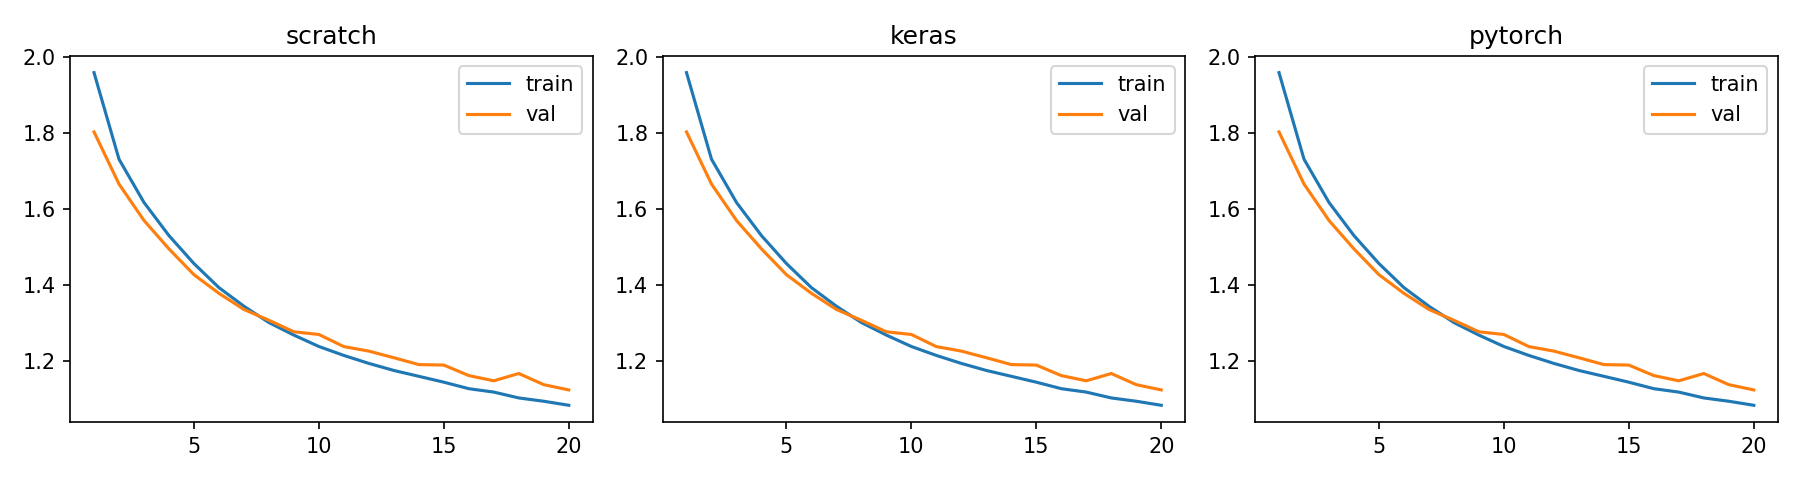

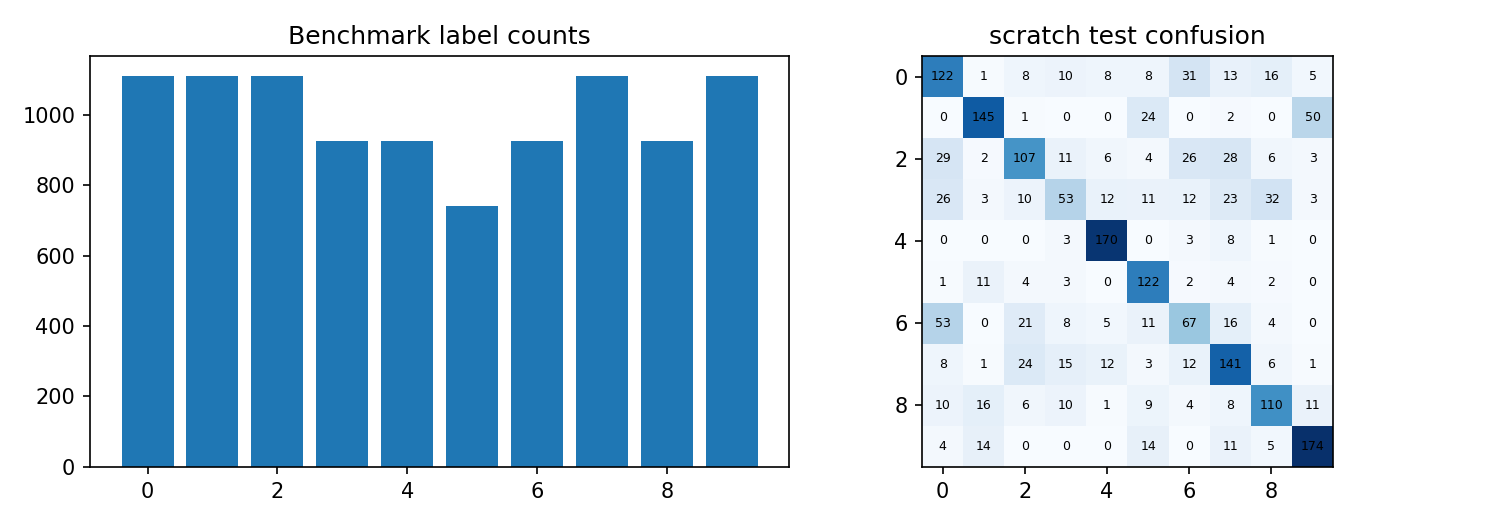

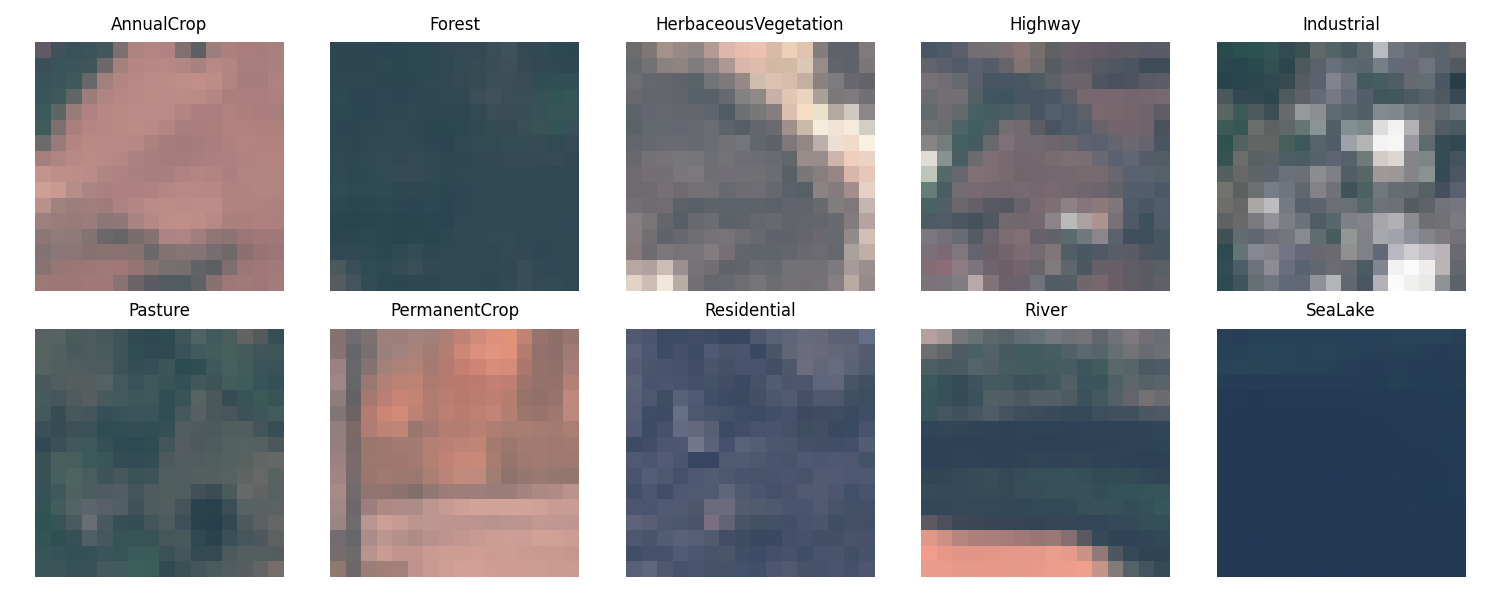

Baseline: {
  "Accuracy": 0.111,
  "MacroF1": 0.01998199819981998
}
Chọn validation: {"framework": "scratch", "criterion": "MacroF1", "split": "validation"}


,index,actual,prediction,score
0,8001,3,7,0.442751
1,8004,0,7,0.528451
2,8007,3,6,0.328111
3,8008,2,6,0.230620
4,8010,3,0,0.662788
5,8011,3,6,0.380561
6,8013,0,2,0.313302
7,8019,6,0,0.294239


In [16]:
display(summarize('eurosat').round(5))
for file in ['learning.png','evaluation.png','samples.png']:
    path=ROOT/'results/eurosat'/file
    if path.exists():display(Image(filename=str(path)))
print('Baseline:',(ROOT/'results/eurosat/baseline.json').read_text())
print('Chọn validation:',(ROOT/'results/eurosat/selection.json').read_text())
display(pd.read_json(ROOT/'results/eurosat/errors.json'))

## 5. Tiểu kết
Mỗi dataset có ba implementation được train độc lập. Kết quả chỉ áp dụng cho cấu hình nhỏ và seed42, chưa có đánh giá nhiều seed. Báo cáo nêu baseline và failure cases; không chọn model bằng test. Kiểm tra gradient bằng tools/check_gradients.py và checkpoint bằng tools/verify.py.